<a href="https://colab.research.google.com/github/raghavkarthikcse2025-coder/daa-lab/blob/main/Exp1%20with%20outputs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import time
import random
import heapq
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import networkx as nx
import numpy as np

# Set a professional plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


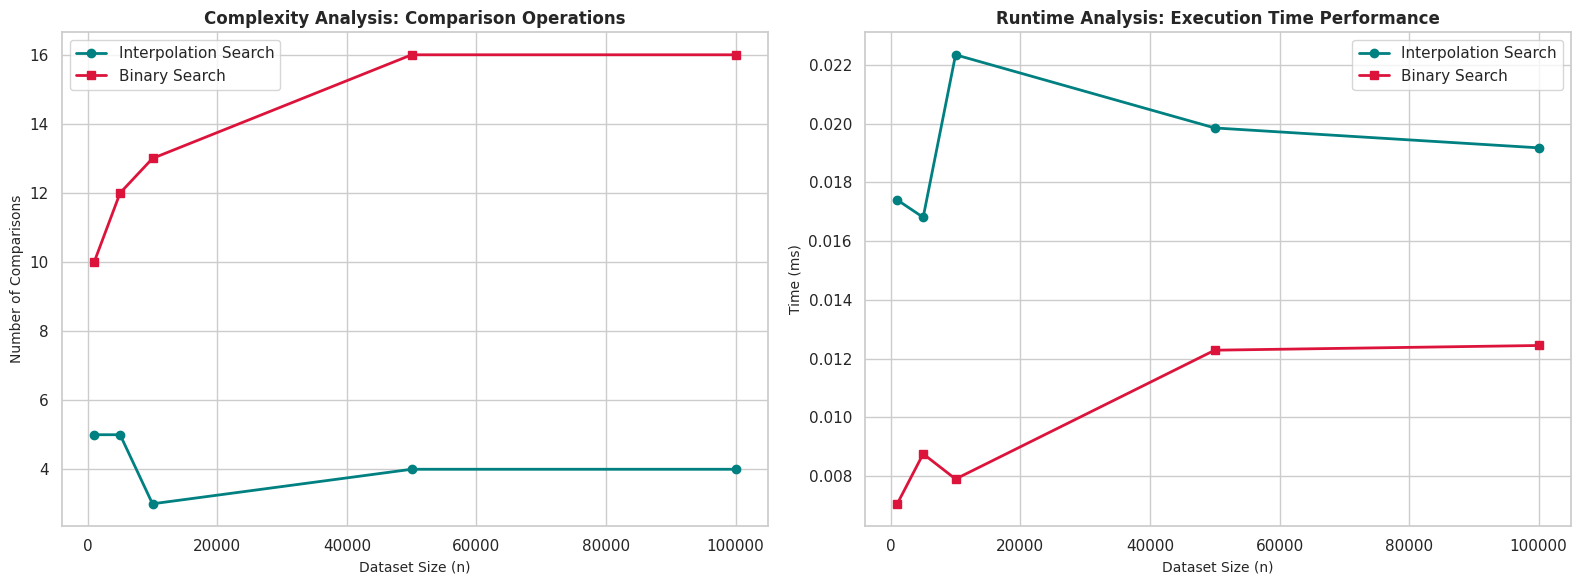

In [2]:
def interpolation_search(arr, target):
    low, high = 0, len(arr) - 1
    comparisons = 0
    while low <= high and arr[low] <= target <= arr[high]:
        comparisons += 1
        if low == high:
            return (low, comparisons) if arr[low] == target else (-1, comparisons)
        pos = low + int(((target - arr[low]) * (high - low)) / (arr[high] - arr[low]))
        if arr[pos] == target:
            return pos, comparisons
        elif arr[pos] < target:
            low = pos + 1
        else:
            high = pos - 1
    return -1, comparisons

def binary_search(arr, target):
    low, high = 0, len(arr) - 1
    comparisons = 0
    while low <= high:
        comparisons += 1
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid, comparisons
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1, comparisons

# Performance Benchmarking & Visualization
sizes = [1000, 5000, 10000, 50000, 100000]
is_times, bs_times = [], []
is_comps, bs_comps = [], []

for size in sizes:
    arr = sorted(random.sample(range(size * 10), size))
    target = arr[random.randint(0, size - 1)]

    # Benchmark Interpolation Search
    start = time.perf_counter()
    _, comp_is = interpolation_search(arr, target)
    is_times.append((time.perf_counter() - start) * 1000)
    is_comps.append(comp_is)

    # Benchmark Binary Search
    start = time.perf_counter()
    _, comp_bs = binary_search(arr, target)
    bs_times.append((time.perf_counter() - start) * 1000)
    bs_comps.append(comp_bs)

# Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Comparison Counts
ax1.plot(sizes, is_comps, marker='o', linewidth=2, color='teal', label='Interpolation Search')
ax1.plot(sizes, bs_comps, marker='s', linewidth=2, color='crimson', label='Binary Search')
ax1.set_title('Complexity Analysis: Comparison Operations', fontsize=12, fontweight='bold')
ax1.set_xlabel('Dataset Size (n)', fontsize=10)
ax1.set_ylabel('Number of Comparisons', fontsize=10)
ax1.legend()

# Subplot 2: Execution Time
ax2.plot(sizes, is_times, marker='o', linewidth=2, color='teal', label='Interpolation Search')
ax2.plot(sizes, bs_times, marker='s', linewidth=2, color='crimson', label='Binary Search')
ax2.set_title('Runtime Analysis: Execution Time Performance', fontsize=12, fontweight='bold')
ax2.set_xlabel('Dataset Size (n)', fontsize=10)
ax2.set_ylabel('Time (ms)', fontsize=10)
ax2.legend()

plt.tight_layout()
plt.show()